# Fair Adult Income Prediction

**We'll build a trustworthy fair classification model on the Adult Income dataset, ensuring decisions do not favor any group based on sensitive attributes.**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from scipy.spatial.distance import cdist
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

import xgboost as xgb

from preprocessing import X, y, P

Loaded: 48842 rows, 100 features
Privileged (Male): 32650, Unprivileged (Female): 16192
Protected ratio: 2.02


In [2]:
# split data 70/10/20
X_train, X_vt, y_train, y_vt, P_train, P_vt = train_test_split(
    X, y, P, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test, P_val, P_test = train_test_split(
    X_vt, y_vt, P_vt, test_size=2/3, random_state=42, stratify=y_vt
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\nTrain samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Protected ratio (Privileged / Unprivileged) in train: {np.sum(P_train==1) / np.sum(P_train==0):.2f}")
print(f"Protected ratio (Privileged / Unprivileged) in val: {np.sum(P_val==1) / np.sum(P_val==0):.2f}")
print(f"Protected ratio (Privileged / Unprivileged) in test: {np.sum(P_test==1) / np.sum(P_test==0):.2f}")


Train samples: 34189
Validation samples: 4884
Test samples: 9769
Protected ratio (Privileged / Unprivileged) in train: 2.02
Protected ratio (Privileged / Unprivileged) in val: 1.95
Protected ratio (Privileged / Unprivileged) in test: 2.05


**Fairness metric:**
True Positive rate and False Positive Rate should be equal across groups.
- returns the maximum difference between groups.
- lower is better (0 = ideal, perfect fairness).

In [3]:
def equalized_odds(y_true, y_pred, P):
  groups = [0, 1]
  tpr, fpr = [], []

  for g in groups:
    mask = (P == g)
    if np.sum(mask) == 0:
      tpr.append(0)
      fpr.append(0)
      continue
    tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask]).ravel()
    tpr.append(tp / (tp + fn) if (tp+fn) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp+tn) > 0 else 0)

  eq_odds = np.maximum(abs(tpr[0]-tpr[1]), abs(fpr[0]-fpr[1]))
  return eq_odds, tpr[0], tpr[1], fpr[0], fpr[1]

In [4]:
xgb_params = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1, # l1 reg
    'reg_lambda': 0.5, # l2 reg
    'scale_pos_weight': (len(y_train) - sum(y_train)) / sum(y_train), # penalizes positive mistakes
    'random_state': 42,
    'eval_metric': 'logloss',
    'verbosity': 0
}

In [5]:
def print_metrics(name, metrics, eq, tpr0, tpr1, fpr0, fpr1):
    print(f"\n{'='*60}")
    print(f"          {name}")
    print('='*60)
    print(f"Accuracy:          {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Precision:         {metrics['precision']:.4f}")
    print(f"Recall:            {metrics['recall']:.4f}")
    print(f"F1 Score:          {metrics['f1']:.4f}")
    print(f"Specificity:       {metrics['specificity']:.4f}")
    print()
    print(f"Equalized Odds:    {eq:.4f}")
    print(f"TPR (Female/Unpriv):   {tpr0:.4f}")
    print(f"TPR (Male/Priv):       {tpr1:.4f}")
    print(f"TPR Difference:    {abs(tpr0 - tpr1):.4f}")
    print(f"FPR (Female/Unpriv):   {fpr0:.4f}")
    print(f"FPR (Male/Priv):       {fpr1:.4f}")
    print(f"FPR Difference:    {abs(fpr0 - fpr1):.4f}")

In [6]:
# confidence intervals
def bootstrap_ci(y_true, y_pred, P, n_boot=500, alpha=0.05):
    n = len(y_true)
    acc_samples = []
    eq_samples = []

    rng = np.random.default_rng(42)

    for _ in range(n_boot):
        i = rng.choice(n, n, replace=True)
        y_boot = y_true[i]
        pred_boot = y_pred[i]
        P_boot = P[i]

        acc_samples.append(accuracy_score(y_boot, pred_boot))
        eq, _, _, _, _ = equalized_odds(y_boot, pred_boot, P_boot)
        eq_samples.append(eq)

    lower_acc = np.percentile(acc_samples, 100 * alpha / 2)
    upper_acc = np.percentile(acc_samples, 100 * (1 - alpha / 2))
    mean_acc = np.mean(acc_samples)

    lower_eq = np.percentile(eq_samples, 100 * alpha / 2)
    upper_eq = np.percentile(eq_samples, 100 * (1 - alpha / 2))
    mean_eq = np.mean(eq_samples)

    return {
        'accuracy': (lower_acc, upper_acc, mean_acc),
        'equalized_odds': (lower_eq, upper_eq, mean_eq)
    }

In [7]:
# k-means and jaccard (for FAPFID)

def kmeans(data, k, max_iter=100):
    rng = np.random.default_rng(42)
    centroids = rng.choice(data, size=k, replace=False)

    for _ in range(max_iter):
        dist = cdist(data, centroids)
        labels = np.argmin(dist, axis=1) # for each sample, assign it to the closest centroid (column index)

        new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return labels

def SIM(labels1, labels2):
    # jaccard similarity between two clusterings
    n = len(labels1)
    both = 0
    either = 0

    assert len(labels1) == len(labels2)

    for i in range(n):
        for j in range(i+1, n):
            in1 = (labels1[i] == labels1[j])
            in2 = (labels2[i] == labels2[j])
            both += in1 and in2
            either += in1 or in2

    # the higher, the more similar
    return both / either if either > 0 else 0


Running stability analysis (Jaccard Distance)...
Best K = 2 (mean distance = 0.2695)


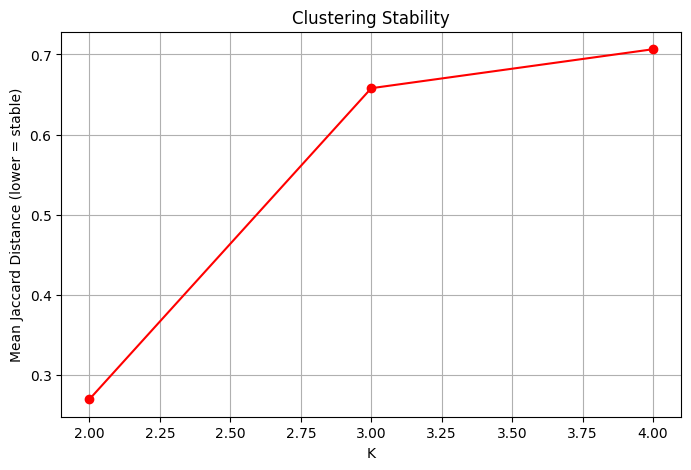

In [8]:
print("\nRunning stability analysis (Jaccard Distance)...")

k_max = range(2, 5)
stability = []
z_max = 5
subsample_size = 0.3
n_samples = len(X_train)
sub_n = int(n_samples * subsample_size)

for k in k_max:
    distances = []

    for _ in range(z_max):

        # consider two independent subsamples
        i1 = np.random.choice(n_samples, sub_n, replace=True)
        i2 = np.random.choice(n_samples, sub_n, replace=True)

        # cluster the subsamples
        l1 = kmeans(X_train[i1], k)
        l2 = kmeans(X_train[i2], k)

        # lower is considered more stable
        distances.append(1 - SIM(l1, l2))

    stability.append(np.mean(distances))

best_k = k_max[np.argmin(stability)]
print(f"Best K = {best_k} (mean distance = {stability[best_k-2]:.4f})")

plt.figure(figsize=(8,5))
plt.plot(k_max, stability, marker='o', color='red')
plt.xlabel('K')
plt.ylabel('Mean Jaccard Distance (lower = stable)')
plt.title('Clustering Stability')
plt.grid(True)
plt.show()

In [10]:
baseline_model = xgb.XGBClassifier(**xgb_params)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

base_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_base),
    'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_base),
    'precision': precision_score(y_test, y_pred_base),
    'recall': recall_score(y_test, y_pred_base),
    'f1': f1_score(y_test, y_pred_base)
}
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_base).ravel()
base_metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0

base_eq, base_tpr0, base_tpr1, base_fpr0, base_fpr1 = equalized_odds(y_test, y_pred_base, P_test)

print_metrics("BASELINE", base_metrics, base_eq, base_tpr0, base_tpr1, base_fpr0, base_fpr1)

base_ci = bootstrap_ci(y_test, y_pred_base, P_test)
print(f"\nBaseline 95% CI - Accuracy: ({base_ci['accuracy'][0]:.4f}, {base_ci['accuracy'][1]:.4f})")
print(f"Baseline 95% CI - EqOdds:  ({base_ci['equalized_odds'][0]:.4f}, {base_ci['equalized_odds'][1]:.4f})")


          BASELINE
Accuracy:          0.8321
Balanced Accuracy: 0.8416
Precision:         0.6049
Recall:            0.8596
F1 Score:          0.7101
Specificity:       0.8235

Equalized Odds:    0.1968
TPR (Female/Unpriv):   0.7639
TPR (Male/Priv):       0.8781
TPR Difference:    0.1141
FPR (Female/Unpriv):   0.0545
FPR (Male/Priv):       0.2514
FPR Difference:    0.1968

Baseline 95% CI - Accuracy: (0.8248, 0.8390)
Baseline 95% CI - EqOdds:  (0.1822, 0.2131)


**Why the Baseline is Unfair and Why We Chose Gender as protected attribute**

The baseline Equalized Odds is 0.1968, well above the 0.1 fairness threshold. This indicates systematic bias in the model's predictions.

The False Positive Rate for men (0.2514) is significantly higher than for women (0.0545). This suggests the model consistently over-estimates men's income, predicting they earn more than 50K even when they do not.

- Initially race was tested as the protected attribute. Despite a protected ratio of 5.90 (White vs Non-White), the baseline Equalized Odds was only 0.066. Race is not strongly correlated with other features in this dataset.

- Gender, however, has a protected ratio of only 2.02 but produces a much higher Equalized Odds of 0.1968. This is because gender is more strongly correlated with features like occupation, hours worked, and education. The model uses these proxies to discriminate.

**To Note**: bias is not determined by how imbalanced the protected groups are.

- It is determined by how predictive the protected attribute remains after accounting for other *relevant* features.
- Gender has historical and social correlations with income, making it the appropriate protected attribute for testing fairness interventions.

---

The 95% confidence interval for the baseline Equalized Odds is (0.1822, 0.2131), which is entirely above the 0.1 fairness threshold. This confirms that the bias is statistically significant and not due to random chance.

In [11]:
labels = kmeans(X_train, best_k)

for i in range(best_k):
    mask = labels == i
    privileged = np.sum(P_train[mask] == 1)
    unprivileged = np.sum(P_train[mask] == 0)
    print(f"Cluster {i}: Privileged: {privileged}, Unprivileged: {unprivileged}, rp={privileged/unprivileged if unprivileged else 0:.2f}")

Cluster 0: Privileged: 15307, Unprivileged: 1552, rp=9.86
Cluster 1: Privileged: 7547, Unprivileged: 9783, rp=0.77


In [12]:
X_bal, P_bal, y_bal = [], [], []

for i in range(best_k):
    mask = labels == i
    Xc, Pc, yc = X_train[mask], P_train[mask], y_train[mask]

    priv_before = np.sum(Pc == 1)
    unpriv_before = np.sum(Pc == 0)

    # over sample the minority group to ensure fair representation in each cluster
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    Xc_res, Pc_res = smote.fit_resample(Xc, Pc)

    # assign y for synthetic samples via nearest neighbor
    dist = cdist(Xc_res, Xc)
    nearest = np.argmin(dist, axis=1)
    yc_res = yc[nearest]

    priv_after = np.sum(Pc_res == 1)
    unpriv_after = np.sum(Pc_res == 0)
    print(f"Cluster {i}: AFTER  SMOTE Privileged : {priv_after}, Unprivileged : {unpriv_after} (Ratio=1.0)")

    X_bal.append(Xc_res)
    P_bal.append(Pc_res)
    y_bal.append(yc_res)

X_bal = np.vstack(X_bal)
P_bal = np.hstack(P_bal)
y_bal = np.hstack(y_bal)

print(f"\nBalanced Dataset: {len(X_bal)} samples")
print(f"Global Ratio: {np.sum(P_bal==1)/np.sum(P_bal==0):.2f} (Ideal = 1.0)")

# Bagging
b = 2 * best_k + 1
ensemble = []
for _ in range(b):
    i = np.random.choice(len(X_bal), len(X_bal), replace=True)
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_bal[i], y_bal[i])
    ensemble.append(model)

def predict_ensemble(X):
    preds = np.array([m.predict(X) for m in ensemble])
    # for each sample, pick the most frequent prediction
    return np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=preds)

Cluster 0: AFTER  SMOTE Privileged : 15307, Unprivileged : 15307 (Ratio=1.0)
Cluster 1: AFTER  SMOTE Privileged : 9783, Unprivileged : 9783 (Ratio=1.0)

Balanced Dataset: 50180 samples
Global Ratio: 1.00 (Ideal = 1.0)


In [13]:
y_pred_fapfid = predict_ensemble(X_test)

fapfid_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_fapfid),
    'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_fapfid),
    'precision': precision_score(y_test, y_pred_fapfid),
    'recall': recall_score(y_test, y_pred_fapfid),
    'f1': f1_score(y_test, y_pred_fapfid)
}
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_fapfid).ravel()
fapfid_metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0

fapfid_eq, fapfid_tpr0, fapfid_tpr1, fapfid_fpr0, fapfid_fpr1 = equalized_odds(y_test, y_pred_fapfid, P_test)

print_metrics("FAPFID (SMOTE)", fapfid_metrics, fapfid_eq, fapfid_tpr0, fapfid_tpr1, fapfid_fpr0, fapfid_fpr1)

fapfid_ci = bootstrap_ci(y_test, y_pred_fapfid, P_test)
print(f"\nFAPFID 95% CI — Accuracy: ({fapfid_ci['accuracy'][0]:.4f}, {fapfid_ci['accuracy'][1]:.4f})")
print(f"FAPFID 95% CI — EqOdds:  ({fapfid_ci['equalized_odds'][0]:.4f}, {fapfid_ci['equalized_odds'][1]:.4f})")


          FAPFID (SMOTE)
Accuracy:          0.8299
Balanced Accuracy: 0.8345
Precision:         0.6033
Recall:            0.8434
F1 Score:          0.7034
Specificity:       0.8256

Equalized Odds:    0.1854
TPR (Female/Unpriv):   0.7480
TPR (Male/Priv):       0.8617
TPR Difference:    0.1137
FPR (Female/Unpriv):   0.0595
FPR (Male/Priv):       0.2448
FPR Difference:    0.1854

FAPFID 95% CI — Accuracy: (0.8223, 0.8367)
FAPFID 95% CI — EqOdds:  (0.1706, 0.2017)


**Why FAPFID (SMOTE) Did Not Work**

- FAPFID achieved a balanced dataset with a 1.00 protected ratio by generating 17,572 synthetic samples. However, Equalized Odds only dropped from 0.1968 to 0.1854, still well above the 0.1 fairness threshold.

- SMOTE balances gender but does not address the underlying issue. The synthetic samples preserve the correlation between gender and proxies like occupation, hours, and education. The model still learns that certain feature combinations are associated with men or women.

- Balancing the label is not the same as balancing the underlying structure. FAPFID failed because bias is embedded in correlated features *(proxy bias)*.

The 95% confidence interval for FAPFID Equalized Odds is (0.1706, 0.2017), which is entirely above the 0.1 fairness threshold.

**Post-Processing:** We train the model once, then adjust decision thresholds separately for each protected group to equalize error rates while maximizing recall.


In [20]:
fair_model = xgb.XGBClassifier(**xgb_params)
fair_model.fit(X_train, y_train)

probs_val = fair_model.predict_proba(X_val)[:, 1]

print("\nSearching for thresholds on validation set that maximize recall while keeping EqOdds < 0.1...")

best_thresholds = {}
best_recall = 0
best_accuracy = 0
best_eq = float('inf')

for th_female in np.linspace(0.25, 0.75, 30):
    for th_male in np.linspace(0.25, 0.75, 30):
        y_pred_temp = np.zeros_like(y_val)
        for i, p in enumerate(P_val):
            if p == 0:
                y_pred_temp[i] = 1 if probs_val[i] >= th_female else 0
            else:
                y_pred_temp[i] = 1 if probs_val[i] >= th_male else 0

        eq_temp, _, _, _, _ = equalized_odds(y_val, y_pred_temp, P_val)

        if eq_temp < 0.075:
            recall_temp = recall_score(y_val, y_pred_temp)
            acc_temp = accuracy_score(y_val, y_pred_temp)

            if recall_temp > best_recall:
                best_recall = recall_temp
                best_accuracy = acc_temp
                best_eq = eq_temp
                best_thresholds = {0: th_female, 1: th_male}

print(f"Optimal thresholds (tuned on validation set): Female : {best_thresholds[0]:.2f}, Male : {best_thresholds[1]:.2f}")
print(f"Best validation EqOdds: {best_eq:.4f}, Best validation Recall: {best_recall:.4f}, Best validation Accuracy: {best_accuracy:.4f}")

probs_test = fair_model.predict_proba(X_test)[:, 1]

y_pred_fair = np.zeros_like(y_test)
for i, p in enumerate(P_test):
    y_pred_fair[i] = 1 if probs_test[i] >= best_thresholds[p] else 0

fair_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_fair),
    'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_fair),
    'precision': precision_score(y_test, y_pred_fair),
    'recall': recall_score(y_test, y_pred_fair),
    'f1': f1_score(y_test, y_pred_fair)
}
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_fair).ravel()
fair_metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0

fair_eq, fair_tpr0, fair_tpr1, fair_fpr0, fair_fpr1 = equalized_odds(y_test, y_pred_fair, P_test)

print_metrics("POST-PROCESSING", fair_metrics, fair_eq, fair_tpr0, fair_tpr1, fair_fpr0, fair_fpr1)

fair_ci = bootstrap_ci(y_test, y_pred_fair, P_test)
print(f"\nPost-Process 95% CI - Accuracy: ({fair_ci['accuracy'][0]:.4f}, {fair_ci['accuracy'][1]:.4f})")
print(f"Post-Process 95% CI - EqOdds:  ({fair_ci['equalized_odds'][0]:.4f}, {fair_ci['equalized_odds'][1]:.4f})")


Searching for thresholds on validation set that maximize recall while keeping EqOdds < 0.1...
Optimal thresholds (tuned on validation set): Female : 0.25, Male : 0.58
Best validation EqOdds: 0.0661, Best validation Recall: 0.8323, Best validation Accuracy: 0.8370

          POST-PROCESSING
Accuracy:          0.8299
Balanced Accuracy: 0.8333
Precision:         0.6038
Recall:            0.8400
F1 Score:          0.7026
Specificity:       0.8267

Equalized Odds:    0.0717
TPR (Female/Unpriv):   0.8886
TPR (Male/Priv):       0.8306
TPR Difference:    0.0580
FPR (Female/Unpriv):   0.1288
FPR (Male/Priv):       0.2006
FPR Difference:    0.0717

Post-Process 95% CI - Accuracy: (0.8222, 0.8367)
Post-Process 95% CI - EqOdds:  (0.0588, 0.0961)


In [21]:
print("\n" + "="*80)
print("                       FINAL COMPARISON")
print("="*80)
print(f"{'Metric':<25} {'Baseline':>12} {'FAPFID':>12} {'Post-Process':>12} {'Best':>12}")
print("-"*80)

metrics = ['accuracy', 'balanced_accuracy', 'recall']
for m in metrics:
    b = base_metrics[m]
    f = fapfid_metrics[m]
    i = fair_metrics[m]
    best = max(b, f, i)
    print(f"{m.replace('_', ' ').title():<25} {b:>12.4f} {f:>12.4f} {i:>12.4f} {best:>12.4f}")

print(f"{'Equalized Odds':<25} {base_eq:>12.4f} {fapfid_eq:>12.4f} {fair_eq:>12.4f} {min(base_eq, fapfid_eq, fair_eq):>12.4f}")
print(f"{'TPR Diff':<25} {abs(base_tpr0-base_tpr1):>12.4f} {abs(fapfid_tpr0-fapfid_tpr1):>12.4f} {abs(fair_tpr0-fair_tpr1):>12.4f} {min(abs(base_tpr0-base_tpr1), abs(fapfid_tpr0-fapfid_tpr1), abs(fair_tpr0-fair_tpr1)):>12.4f}")
print(f"{'FPR Diff':<25} {abs(base_fpr0-base_fpr1):>12.4f} {abs(fapfid_fpr0-fapfid_fpr1):>12.4f} {abs(fair_fpr0-fair_fpr1):>12.4f} {min(abs(base_fpr0-base_fpr1), abs(fapfid_fpr0-fapfid_fpr1), abs(fair_fpr0-fair_fpr1)):>12.4f}")
print("="*80)


                       FINAL COMPARISON
Metric                        Baseline       FAPFID Post-Process         Best
--------------------------------------------------------------------------------
Accuracy                        0.8321       0.8299       0.8299       0.8321
Balanced Accuracy               0.8416       0.8345       0.8333       0.8416
Recall                          0.8596       0.8434       0.8400       0.8596
Equalized Odds                  0.1968       0.1854       0.0717       0.0717
TPR Diff                        0.1141       0.1137       0.0580       0.0580
FPR Diff                        0.1968       0.1854       0.0717       0.0717


**The constrained threshold search achieved Equalized Odds of 0.0717, below the 0.1 fairness threshold. Recall (0.8400) and Accuracy (0.8333).**

The optimal thresholds were Female=0.25 and Male=0.58. This means:

- For women, the model predicts income >50K if the probability exceeds 0.25.
- For men, the model predicts income >50K if the probability exceeds 0.58.

The higher threshold for men compensates for the model's tendency to over-predict men's income. This adjustment reduced the False Positive Rate gap from 0.1968 to 0.0717.

The model now treats both groups fairly while preserving predictive performance.


Visualization saved as 'fairness_comparison.png'


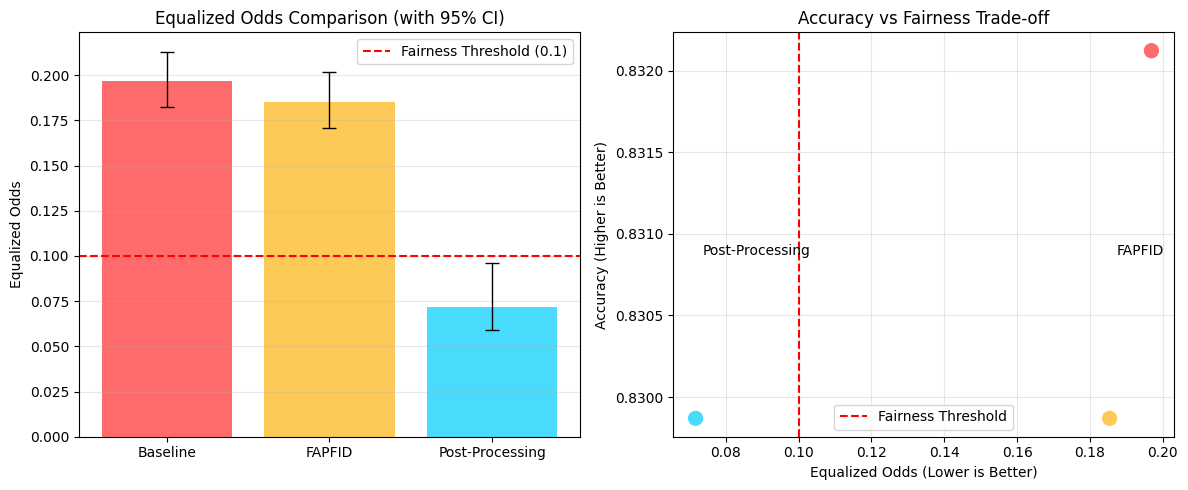

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Baseline', 'FAPFID', 'Post-Processing']
eq_odds = [base_eq, fapfid_eq, fair_eq]
eq_ci_lower = [base_ci['equalized_odds'][0], fapfid_ci['equalized_odds'][0], fair_ci['equalized_odds'][0]]
eq_ci_upper = [base_ci['equalized_odds'][1], fapfid_ci['equalized_odds'][1], fair_ci['equalized_odds'][1]]
eq_err = [ [eq_odds[i] - eq_ci_lower[i], eq_ci_upper[i] - eq_odds[i]] for i in range(3) ]

colors = ['#ff6b6b', '#feca57', '#48dbfb']

axes[0].bar(models, eq_odds, yerr=np.array(eq_err).T, capsize=5, color=colors, error_kw={'ecolor': 'black', 'linewidth': 1})
axes[0].axhline(y=0.1, color='red', linestyle='--', label='Fairness Threshold (0.1)')
axes[0].set_ylabel('Equalized Odds')
axes[0].set_title('Equalized Odds Comparison (with 95% CI)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

accuracies = [base_metrics['accuracy'], fapfid_metrics['accuracy'], fair_metrics['accuracy']]
acc_ci_lower = [base_ci['accuracy'][0], fapfid_ci['accuracy'][0], fair_ci['accuracy'][0]]
acc_ci_upper = [base_ci['accuracy'][1], fapfid_ci['accuracy'][1], fair_ci['accuracy'][1]]
acc_err = [ [accuracies[i] - acc_ci_lower[i], acc_ci_upper[i] - accuracies[i]] for i in range(3) ]

axes[1].scatter(eq_odds, accuracies, color=colors, s=100)
for i, model in enumerate(models):
    axes[1].annotate(model, (eq_odds[i] + 0.002, accuracies[i] + 0.001))
axes[1].axvline(x=0.1, color='red', linestyle='--', label='Fairness Threshold')
axes[1].set_xlabel('Equalized Odds (Lower is Better)')
axes[1].set_ylabel('Accuracy (Higher is Better)')
axes[1].set_title('Accuracy vs Fairness Trade-off')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fairness_comparison.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved as 'fairness_comparison.png'")
plt.show()